# Laws of RankMe Evolution

In [1]:
%pip install -q pandas numpy matplotlib seaborn scipy

/home/mattia/Documents/GitHub/EPFL/open-project-m2-jpmg/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


In this notebook, we investigate whether different languages share the same geometric phases in their RankMe training curves, regardless of magnitude. We approach in two ways: by analyzing normalized curves, and by fitting shared parametric laws across all languages. We focus on the RankMe of last-token representations at the last layer.

In [2]:
import pandas as pd
import os
import sys

REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))

sys.path.insert(0, os.path.join(REPO_ROOT, "code", "visualization"))
sys.path.insert(0, os.path.join(REPO_ROOT, "code", "geometry_analysis"))

from visualize_shaded_pt_curves import show_training_curves
from fit_rankme import fit_rankme_from_df, plot_fitted_laws, FuxiSharedACModel, FuxiPerLangACModel, ApertusSharedACModel, ApertusPerLangACModel, ApertusDualTailACModel, ApertusDualLamACModel

In [3]:
def display_parameter_tables(params_df):
    skip = {"language", "r2", "sse", "layer", "aggregation"}
    numeric_cols = [c for c in params_df.columns if c not in skip]

    shared_cols = [c for c in numeric_cols if params_df[c].nunique() == 1]
    per_lang_cols = [c for c in numeric_cols if params_df[c].nunique() > 1]

    print("Shared parameters:")
    display(params_df[shared_cols].iloc[[0]].reset_index(drop=True).round(4))

    print("Per-language parameters:")
    display(params_df[["language"] + per_lang_cols + ["r2"]].reset_index(drop=True).round(4))

## FuxiTranyu 8B

We first visualize the RankMe curves of last-token representations at the last layer for FuxiTranyu 8B.

In [4]:
CSV_PATH = os.path.join(REPO_ROOT, "code", "results", "fuxi_fine_wiki.csv")

fuxi_df = pd.read_csv(CSV_PATH)
print(f"Loaded {len(fuxi_df):,} rows from {CSV_PATH}")
fuxi_df.head()

Loaded 48,720 rows from /home/mattia/Documents/GitHub/EPFL/open-project-m2-jpmg/code/results/fuxi_fine_wiki.csv


,checkpoint,dataset,layer,aggregation,rankme,pr,alpha_req,top_1_var,top_5_var,top_10_var,top_25_var,top_50_var,top_100_var,top_250_var,top_500_var,top_1000_var
0,10B,English,layer_0,last,176.2048,25.4827,1.358558,0.1808,0.2912,0.3473,0.4456,0.5564,0.6930,0.8630,0.9478,0.9855
1,10B,English,layer_1,last,212.2066,22.1531,1.082762,0.2019,0.2897,0.3386,0.4232,0.5179,0.6426,0.8112,0.9109,0.9682
2,10B,English,layer_2,last,218.9397,21.4111,0.986896,0.2043,0.3008,0.3510,0.4333,0.5222,0.6385,0.7964,0.8938,0.9567
3,10B,English,layer_3,last,229.1743,22.3187,0.936015,0.1975,0.3118,0.3620,0.4414,0.5248,0.6335,0.7824,0.8789,0.9470
4,10B,English,layer_4,last,236.1098,23.6482,0.901771,0.1855,0.3225,0.3710,0.4488,0.5275,0.6298,0.7715,0.8669,0.9392


In [5]:
checkpoints = sorted(fuxi_df["checkpoint"].unique(), key=lambda x: int(x.replace("B", "")) if x[0].isdigit() else float("inf"))
languages = sorted(fuxi_df["dataset"].unique())
layers = sorted(fuxi_df["layer"].unique(), key=lambda x: int(x.split("_")[1]))
aggregations = sorted(fuxi_df["aggregation"].unique())
metric_cols = [c for c in fuxi_df.columns if c not in ("checkpoint", "dataset", "layer", "aggregation")]

print(f"Total rows: {len(fuxi_df):,}")
print(f"Checkpoints ({len(checkpoints)}): {checkpoints}")
print(f"Languages ({len(languages)}): {languages}")
print(f"Layers ({len(layers)}): {[layer.split('_')[1] for layer in layers]}")
print(f"Aggregations ({len(aggregations)}): {aggregations}")
print(f"Metrics ({len(metric_cols)}): {metric_cols}")

Total rows: 48,720
Checkpoints (58): ['10B', '21B', '31B', '42B', '52B', '63B', '73B', '84B', '94B', '105B', '115B', '126B', '136B', '147B', '157B', '168B', '178B', '189B', '199B', '210B', '220B', '231B', '241B', '252B', '262B', '273B', '283B', '294B', '304B', '315B', '325B', '334B', '342B', '352B', '363B', '373B', '384B', '394B', '405B', '415B', '426B', '436B', '447B', '457B', '468B', '478B', '489B', '499B', '510B', '520B', '531B', '541B', '552B', '562B', '573B', '583B', '593B', 'main']
Languages (14): ['Arabic', 'Chinese', 'English', 'Finnish', 'French', 'German', 'Hindi', 'Indonesian', 'Italian', 'Japanese', 'Spanish', 'Swahili', 'Turkish', 'Vietnamese']
Layers (30): ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29']
Aggregations (2): ['last', 'mean']
Metrics (12): ['rankme', 'pr', 'alpha_req', 'top_1_var', 'top_5_var', 'top_10_var', 'top_25_var', 'top_50_var', 'to

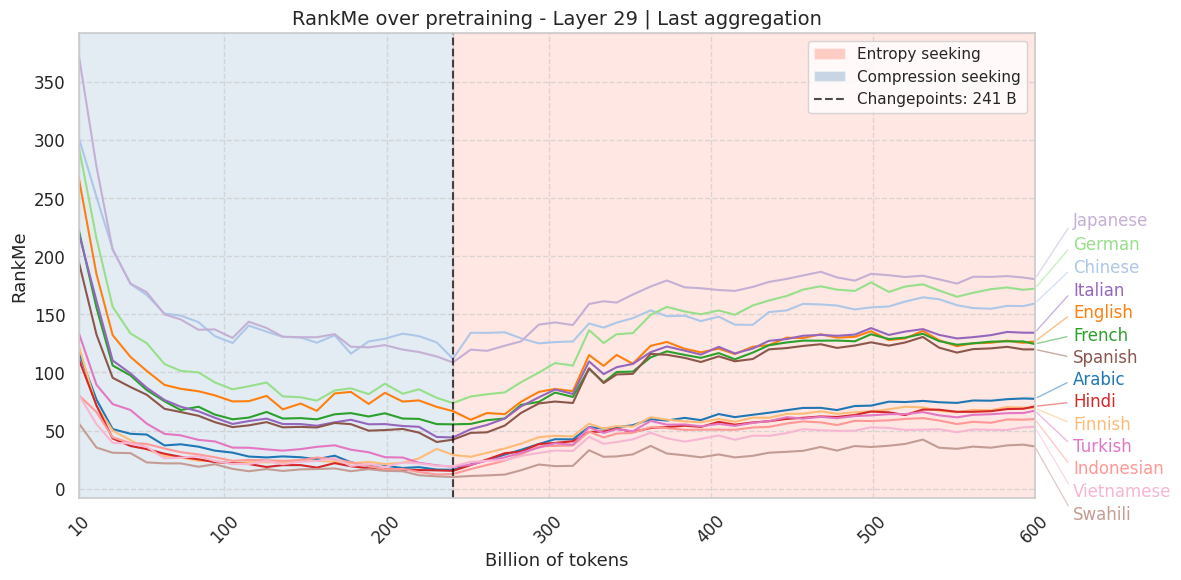

In [6]:
show_training_curves(fuxi_df, metrics=["rankme"], layers=["layer_29"], aggregations=["last"], main_value=600, smoothing=1, path="../plots/report/fuxi", img_format="svg")

### Normalized curves

We normalize curves by applying min-max scaling independently within each phase (per-segment normalization), mapping each language's curve to [0, 1] per phase to remove magnitude differences while preserving shape.

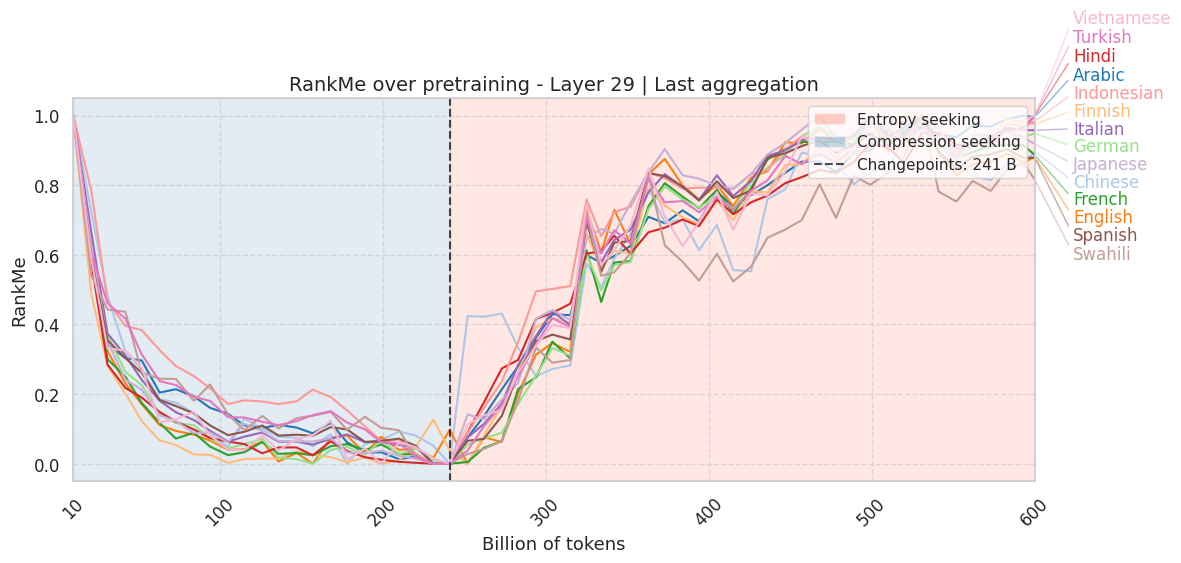

In [7]:
show_training_curves(fuxi_df, metrics=["rankme"], layers=["layer_29"], aggregations=["last"], smoothing=1, main_value=600, normalize="per-segment", path="../plots/report/fuxi", img_format="svg")

### Shared power-law + saturation model

The normalized curves show that all languages follow the same shape, differing only in magnitude and offset. This motivates a model $\hat{R}(t)$ of RankMe at time $t$ of the form

$$\hat{R}(t) = \alpha + \beta \, f(t)$$

where $\alpha$ is a per-language offset, $\beta$ is a per-language magnitude, and $f$ is a shared shape function. 

The curves show an initial power-law decrease followed by a bounded recovery, so we define $f$ as a two-phase piecewise function:

$$f(t) = \begin{cases} t^{-\gamma} & t \le t_1 \\ P_1 + C\!\left(1 - e^{-(t-t_1)/\lambda}\right) & t > t_1 \end{cases}$$

where $P_1 = t_1^{-\gamma}$ ensures continuity, and $\gamma$, $C$ and $\lambda$ are shared parameters. In particular:
- $\gamma$ is the power-law decay exponent, 
- $C$ is the amplitude of the phase-2 recovery, 
- $\lambda$ is the timescale of phase-2 recovery.

In [8]:
fuxi_shared_model = FuxiSharedACModel()
fuxi_shared_params_df = fit_rankme_from_df(fuxi_df, layer="layer_29", aggregation="last", model=fuxi_shared_model, changepoints=[241])
display_parameter_tables(fuxi_shared_params_df)

Shared parameters:


,gamma,C,lam,t_change
0,0.7385,0.0715,115.7193,241.0


Per-language parameters:


,language,alpha,beta,r2
0,Arabic,8.1092,728.2742,0.9420
1,Chinese,101.6598,826.4393,0.6887
2,English,42.1712,1116.1133,0.9291
3,Finnish,9.5926,667.3988,0.9185
4,French,33.2476,1110.1104,0.9607
5,German,46.9077,1466.4179,0.9687
6,Hindi,4.5467,686.7703,0.9401
7,Indonesian,10.9814,528.1406,0.8894
8,Italian,27.2816,1229.4079,0.9563
9,Japanese,86.6996,1309.0271,0.8915


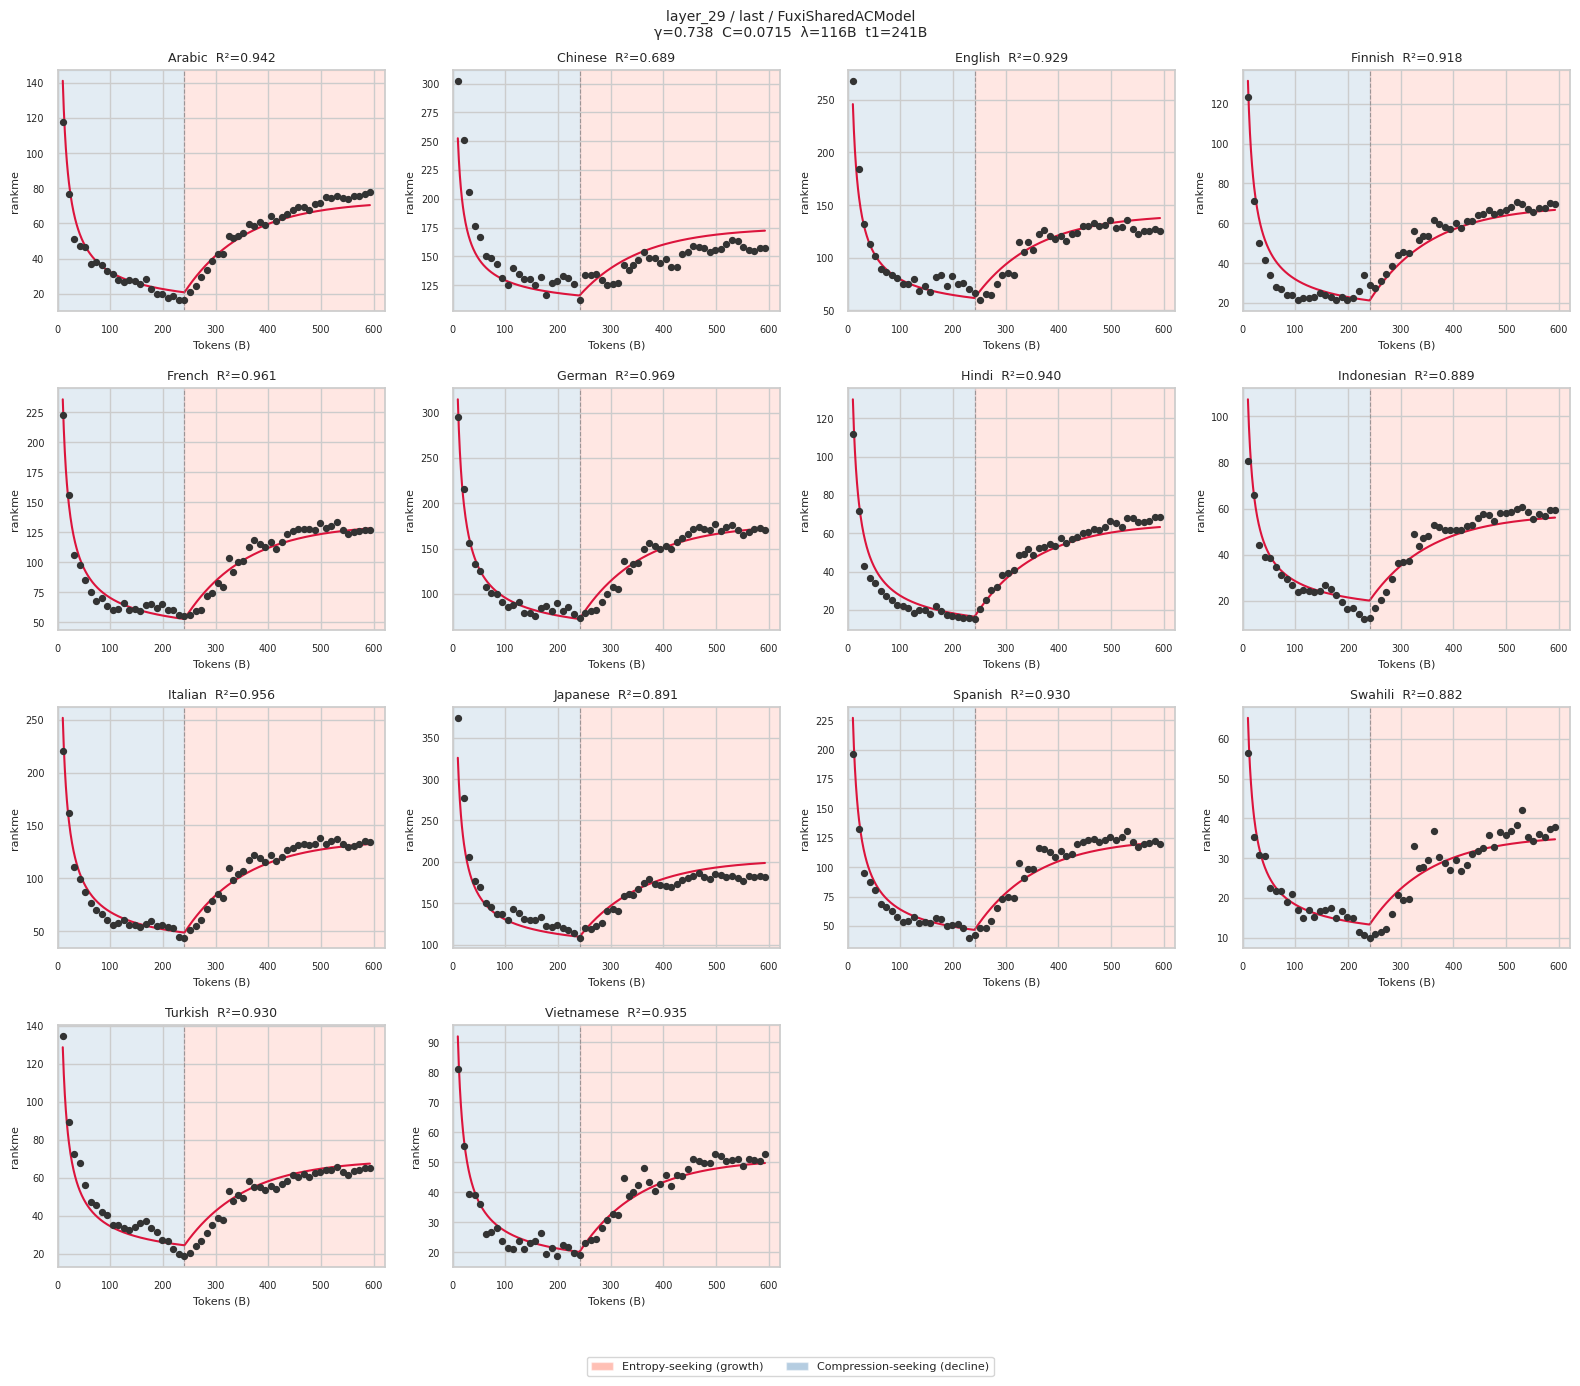

In [9]:
plot_fitted_laws(fuxi_shared_params_df, fuxi_df, model=fuxi_shared_model)

### Per-language amplitude model

The shared model achieves R² below 0.70 for Chinese, suggesting the amplitude varies per language even if the shape does not. We therefore make $A$ and $C$ per-language linear parameters, keeping only $\gamma$ and $\lambda$ shared.

The power law is clamped at its plateau value after the changepoint, so the model is piecewise and continuous at $t_1$:

$$\hat{R}(t) = \begin{cases} \alpha + A\,t^{-\gamma} & t \le t_1 \\ \alpha + A\,P_1 + C\!\left(1 - e^{-(t-t_1)/\lambda}\right) & t > t_1 \end{cases}$$

where $P_1 = t_1^{-\gamma}$.

In [10]:
fuxi_perlang_model = FuxiPerLangACModel()
fuxi_perlang_params_df = fit_rankme_from_df(fuxi_df, layer="layer_29", aggregation="last", model=fuxi_perlang_model, changepoints=[241])
display_parameter_tables(fuxi_perlang_params_df)

Shared parameters:


,gamma,lam,t_change
0,0.7344,115.0655,241.0


Per-language parameters:


,language,alpha,A,C,r2
0,Arabic,8.2602,609.9625,58.6428,0.9860
1,Chinese,100.1579,1177.6130,38.1485,0.9426
2,English,41.4375,1216.3906,73.3857,0.9466
3,Finnish,9.7172,564.9063,53.3781,0.9561
4,French,33.1563,1024.7064,83.8215,0.9694
5,German,46.6616,1388.7380,108.6802,0.9724
6,Hindi,4.7106,569.7133,55.6157,0.9885
7,Indonesian,11.1610,420.2703,43.8329,0.9570
8,Italian,27.3431,1085.3111,95.7453,0.9786
9,Japanese,85.2963,1582.7701,76.9470,0.9743


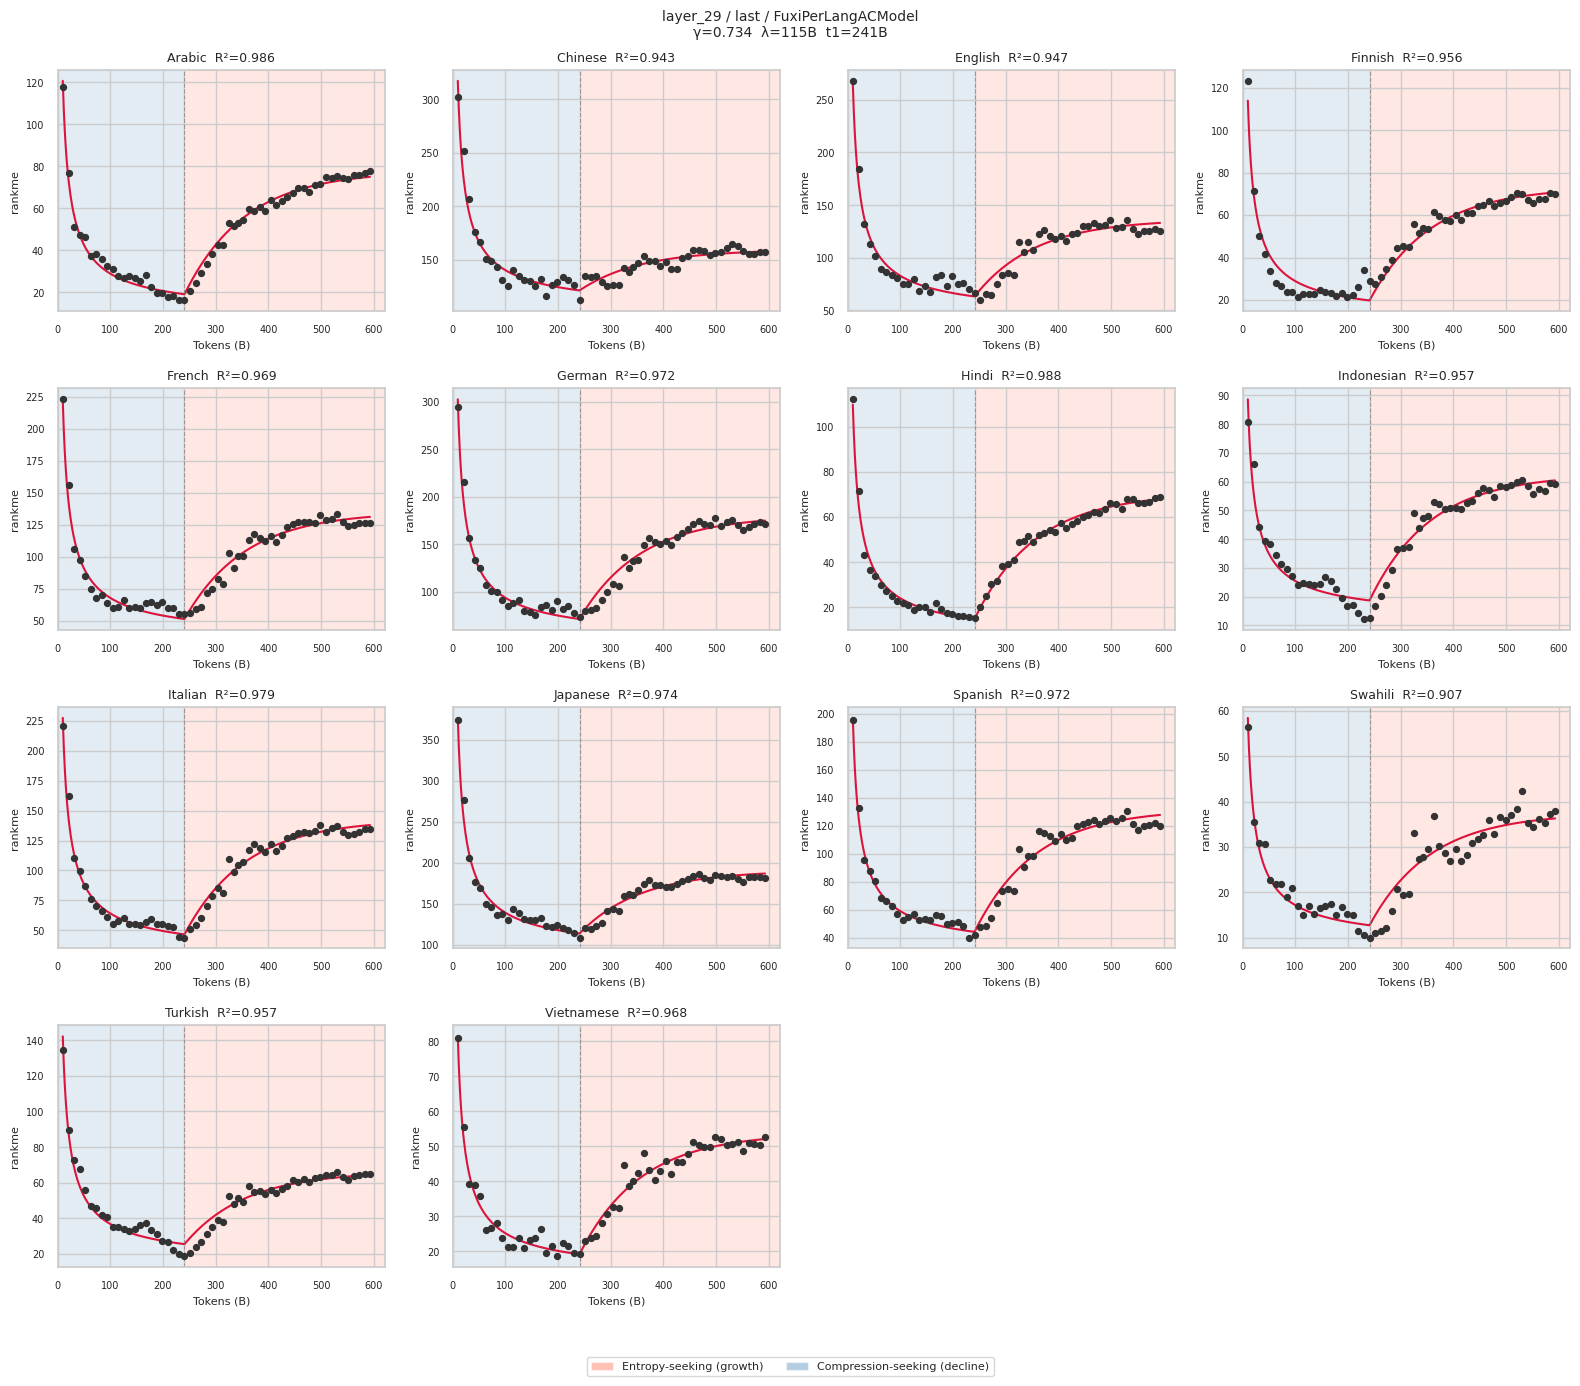

In [11]:
plot_fitted_laws(fuxi_perlang_params_df, fuxi_df, model=fuxi_perlang_model)

Making $A$ and $C$ per-language brings all 14 languages above R² = 0.90 (minimum: Swahili at 0.91), confirming that $\gamma$ and $\lambda$ are shared across languages.

## Apertus 8B

We first visualize the RankMe curves of last-token representations at the last layer for Apertus 8B.

In [12]:
CSV_PATH = os.path.join(REPO_ROOT, "code", "results", "apertus_fine_wiki.csv")

apertus_df = pd.read_csv(CSV_PATH)
print(f"Loaded {len(apertus_df):,} rows from {CSV_PATH}")
apertus_df.head()

Loaded 40,320 rows from /home/mattia/Documents/GitHub/EPFL/open-project-m2-jpmg/code/results/apertus_fine_wiki.csv


,checkpoint,dataset,layer,aggregation,rankme,pr,alpha_req,top_1_var,top_5_var,top_10_var,top_25_var,top_50_var,top_100_var,top_250_var,top_500_var,top_1000_var
0,step50000-tokens210B,English,layer_0,last,5.8682,1.5762,1.188366,0.7962,0.8309,0.8427,0.8605,0.8777,0.8991,0.9328,0.9609,0.9854
1,step50000-tokens210B,English,layer_1,last,7.5185,1.6438,0.806348,0.7798,0.8064,0.8165,0.8329,0.8488,0.8688,0.9022,0.9330,0.9657
2,step50000-tokens210B,English,layer_2,last,9.9573,2.1356,0.731912,0.6738,0.8088,0.8189,0.8340,0.8486,0.8668,0.8981,0.9279,0.9607
3,step50000-tokens210B,English,layer_3,last,20.5941,2.7820,0.691209,0.5892,0.7239,0.7403,0.7627,0.7829,0.8080,0.8511,0.8927,0.9396
4,step50000-tokens210B,English,layer_4,last,48.5817,4.2219,0.668665,0.4745,0.6192,0.6430,0.6747,0.7025,0.7362,0.7943,0.8504,0.9142


In [13]:
checkpoints = sorted(apertus_df["checkpoint"].unique(), key=lambda x: int(x.replace("B", "")) if x[0].isdigit() else float("inf"))
languages = sorted(apertus_df["dataset"].unique())
layers = sorted(apertus_df["layer"].unique(), key=lambda x: int(x.split("_")[1]))
aggregations = sorted(apertus_df["aggregation"].unique())
metric_cols = [c for c in apertus_df.columns if c not in ("checkpoint", "dataset", "layer", "aggregation")]

print(f"Total rows: {len(apertus_df):,}")
print(f"Checkpoints ({len(checkpoints)}): {checkpoints}")
print(f"Languages ({len(languages)}): {languages}")
print(f"Layers ({len(layers)}): {[layer.split('_')[1] for layer in layers]}")
print(f"Aggregations ({len(aggregations)}): {aggregations}")
print(f"Metrics ({len(metric_cols)}): {metric_cols}")

Total rows: 40,320
Checkpoints (45): ['step50000-tokens210B', 'step100000-tokens420B', 'step150000-tokens630B', 'step200000-tokens840B', 'step250000-tokens1050B', 'step300000-tokens1260B', 'step350000-tokens1470B', 'step400000-tokens1680B', 'step450000-tokens1890B', 'step500000-tokens2100B', 'step550000-tokens2310B', 'step600000-tokens2520B', 'step650000-tokens2730B', 'step700000-tokens2940B', 'step750000-tokens3150B', 'step800000-tokens3360B', 'step850000-tokens3570B', 'step900000-tokens3780B', 'step950000-tokens3990B', 'step1000000-tokens4200B', 'step1194000-tokens5014B', 'step1432000-tokens6014B', 'step1670000-tokens7014B', 'step1678000-tokens7047B', 'step1700000-tokens7232B', 'step1750000-tokens7652B', 'step1800000-tokens8072B', 'step1850000-tokens8492B', 'step1900000-tokens8912B', 'step1950000-tokens9332B', 'step2000000-tokens9752B', 'step2050000-tokens10172B', 'step2100000-tokens10592B', 'step2150000-tokens11012B', 'step2200000-tokens11432B', 'step2250000-tokens11852B', 'step2300

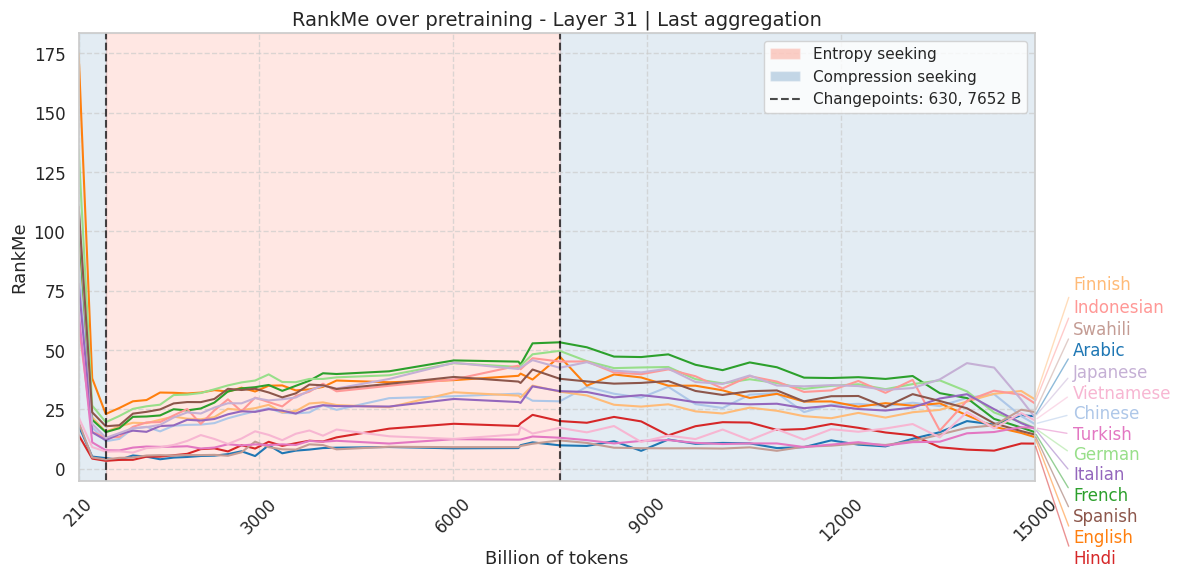

In [14]:
show_training_curves(apertus_df, metrics=["rankme"], layers=["layer_31"], aggregations=["last"], smoothing=0.2, path="../plots/report/apertus", img_format="svg")

We now apply the same per-phase min-max scaling already used for FuxiTranyu.

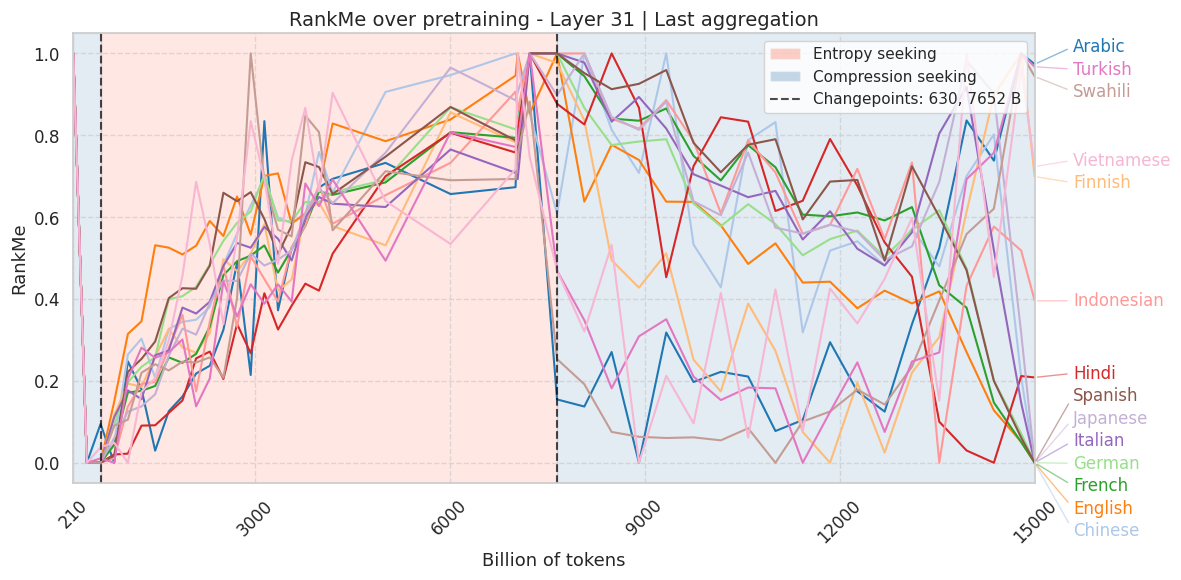

In [15]:
show_training_curves(apertus_df, metrics=["rankme"], layers=["layer_31"], aggregations=["last"], smoothing=0.20, normalize="per-segment", path="../plots/report/apertus", img_format="svg")

### Three-phase shared model

The normalized Apertus curves show language sharing the same shape in the first two phases, but largely differing in the last one. Despite this, we try to use the same $\hat{R}(t) = \alpha + \beta\,f(t)$ structure already applied with FuxiTranyu, with $\alpha, \beta$ per-language and $f$ shared.

The curves exhibit two inflections: a plateau beginning around $t_1 \approx 630\,\text{B}$ and a second transition around $t_2 \approx 7.6\,\text{T}$. Therefore, we extend $f$ to three phases:

$$f(t) = \begin{cases} t^{-\gamma} & t \le t_1 \\ P_1 + C_2\!\left(1 - e^{-(t-t_1)/\lambda_2}\right) & t_1 < t \le t_2 \\ P_2 + C_3\!\left(1 - e^{-(t-t_2)/\lambda_3}\right) & t > t_2 \end{cases}$$

where $P_1 = t_1^{-\gamma}$ and $P_2 = P_1 + C_2\!\left(1 - e^{-(t_2-t_1)/\lambda_2}\right)$ ensure continuity, and $\gamma, C_2, \lambda_2, C_3, \lambda_3$ are shared across all languages. In particular:
- $\gamma$ is the power-law decay exponent,
- $C_2$ is the amplitude of the phase-2 recovery,
- $\lambda_2$ is the timescale of phase-2 recovery,
- $C_3$ is the amplitude of the phase-3 change,
- $\lambda_3$ is the timescale of phase-3 change.

In [16]:
apertus_shared_model = ApertusSharedACModel()
apertus_shared_params_df = fit_rankme_from_df(apertus_df, "layer_31", "last", model=apertus_shared_model, changepoints=[630, 7652], t_scale=1000)
display_parameter_tables(apertus_shared_params_df)

Shared parameters:


,gamma,C2,lam2,C3,lam3,t_change,t_change2
0,3.7341,0.0,4261.1607,-0.0,7348.0,630.0,7652.0


Per-language parameters:


,language,alpha,beta,r2
0,Arabic,8.0242,4.904803e+09,0.1009
1,Chinese,14.2914,3.491469e+10,0.9141
2,English,10.5197,7.076402e+10,0.9009
3,Finnish,13.8750,3.805733e+10,0.9118
4,French,21.1465,4.432697e+10,0.8300
5,German,18.4962,5.428966e+10,0.9600
6,Hindi,9.9916,7.644009e+09,0.1665
7,Indonesian,23.1630,2.475883e+10,0.5549
8,Italian,15.2667,3.053811e+10,0.9195
9,Japanese,18.3626,4.546392e+10,0.8799


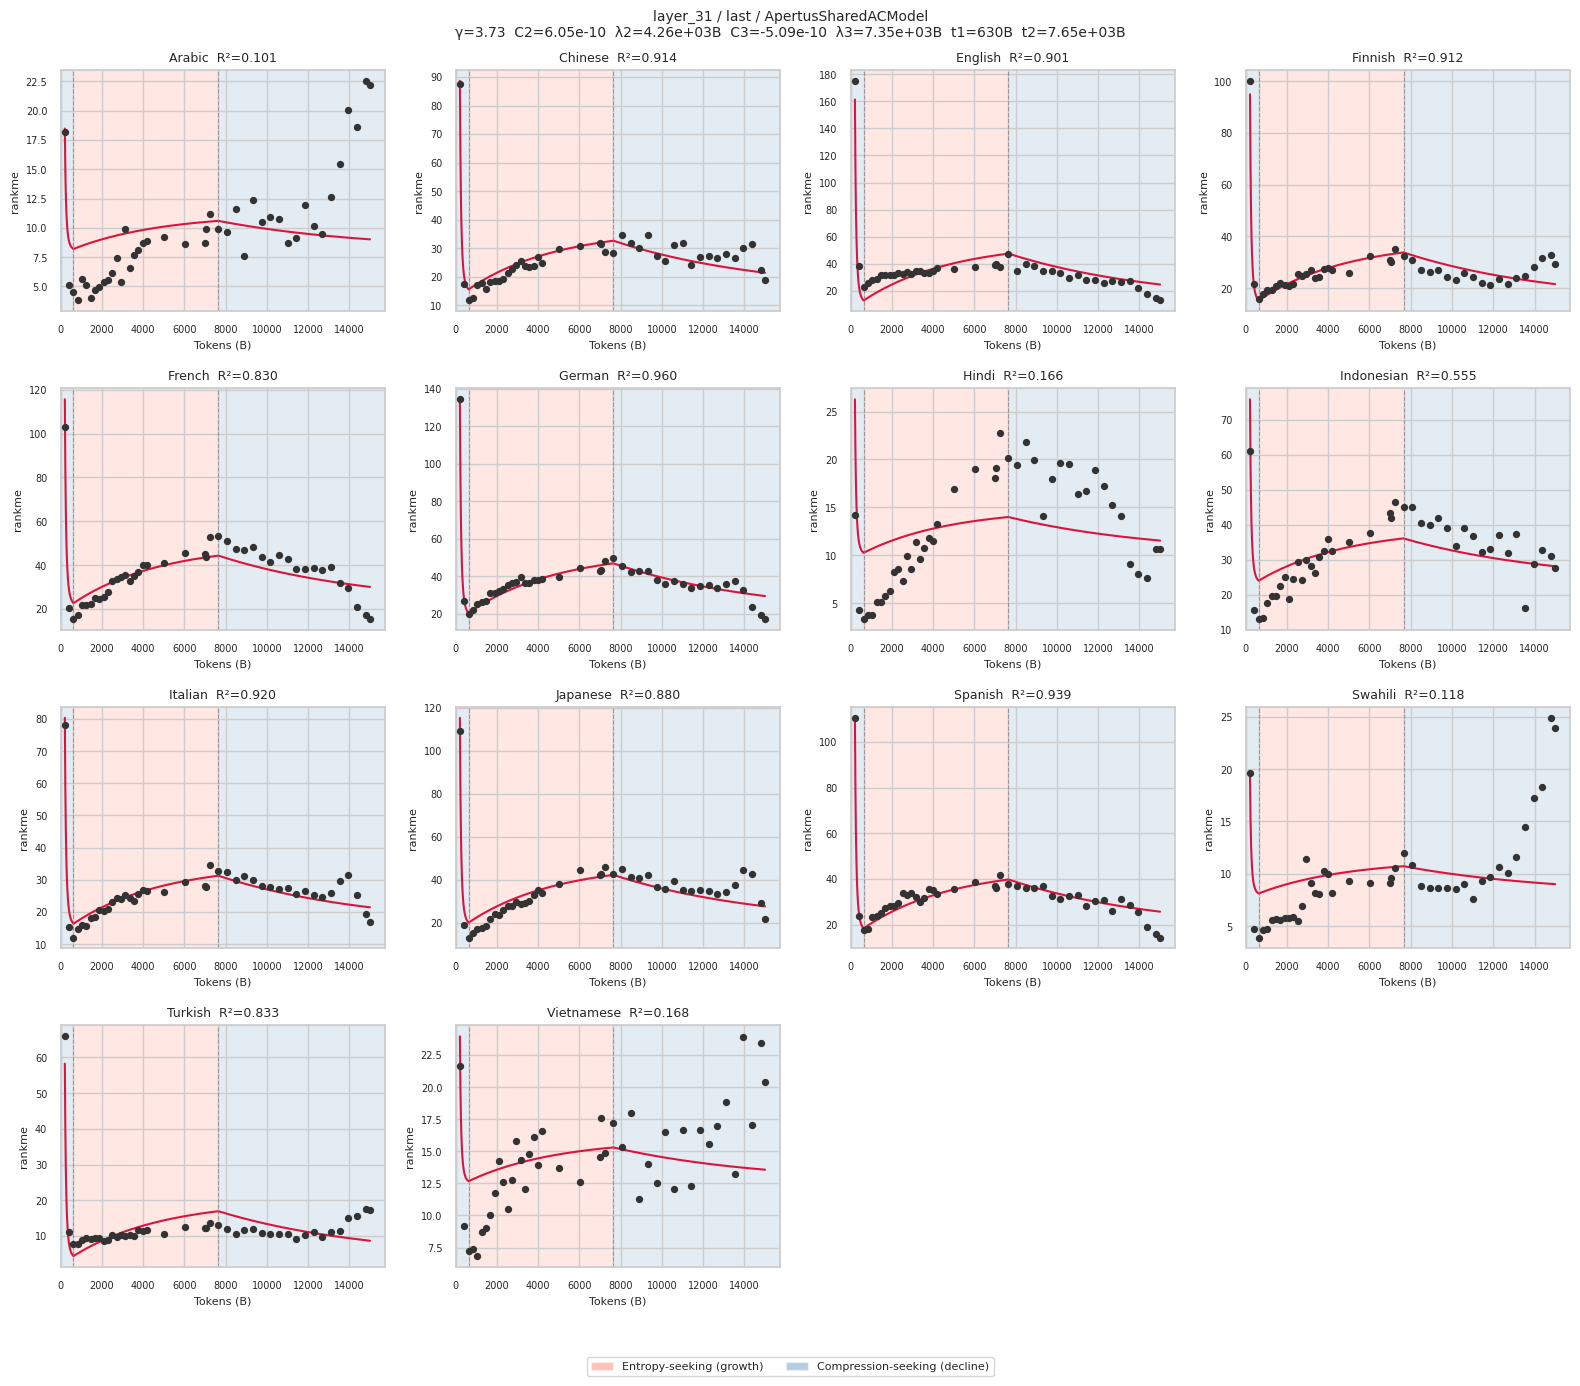

In [17]:
plot_fitted_laws(apertus_shared_params_df, apertus_df, model=apertus_shared_model)

### Three-phase per-language amplitude model

The shared model fails for Arabic, Swahili, Hindi and Vietnamese (R²<0.2). These four languages display a final expansion in the third phase, while the remaining languages compress. We attempt to fix the poor fit by making $A$, $C_2$, $C_3$ per-language linear parameters, keeping only $\gamma, \lambda_2, \lambda_3$ shared.

Each phase's basis is clamped at its plateau value at the next changepoint, giving a piecewise-continuous model:

$$\hat{R}(t) = \begin{cases} \alpha + A\,t^{-\gamma} & t \le t_1 \\ \alpha + A\,P_1 + C_2\!\left(1 - e^{-(t-t_1)/\lambda_2}\right) & t_1 < t \le t_2 \\ \alpha + A\,P_1 + C_2\,Q_2 + C_3\!\left(1 - e^{-(t-t_2)/\lambda_3}\right) & t > t_2 \end{cases}$$

where $P_1 = t_1^{-\gamma}$ and $Q_2 = 1 - e^{-(t_2-t_1)/\lambda_2}$.

In [18]:
apertus_model_per_lang = ApertusPerLangACModel()
apertus_params_per_language_df = fit_rankme_from_df(apertus_df, "layer_31", "last", model=apertus_model_per_lang, changepoints=[630, 7652], t_scale=1000)
display_parameter_tables(apertus_params_per_language_df)

Shared parameters:


,gamma,lam2,lam3,t_change,t_change2
0,3.8601,4895.1375,7348.0,630.0,7652.0


Per-language parameters:


,language,alpha,A,C2,C3,r2
0,Arabic,4.2352,1.282408e+10,5.7890,11.8916,0.7339
1,Chinese,11.9524,6.964690e+10,25.2394,-10.9245,0.9540
2,English,24.3492,1.389067e+11,19.6008,-33.9563,0.9871
3,Finnish,16.7219,7.678275e+10,16.1815,-8.6635,0.9432
4,French,13.7961,8.224078e+10,48.8385,-39.9541,0.9315
5,German,20.8469,1.045309e+11,33.2236,-33.6013,0.9669
6,Hindi,1.0430,1.225311e+10,25.5163,-14.4965,0.8595
7,Indonesian,12.1365,4.513897e+10,41.3234,-24.9685,0.8984
8,Italian,12.8016,5.989903e+10,24.2487,-13.7924,0.9481
9,Japanese,12.0158,8.958241e+10,40.5717,-18.6000,0.9528


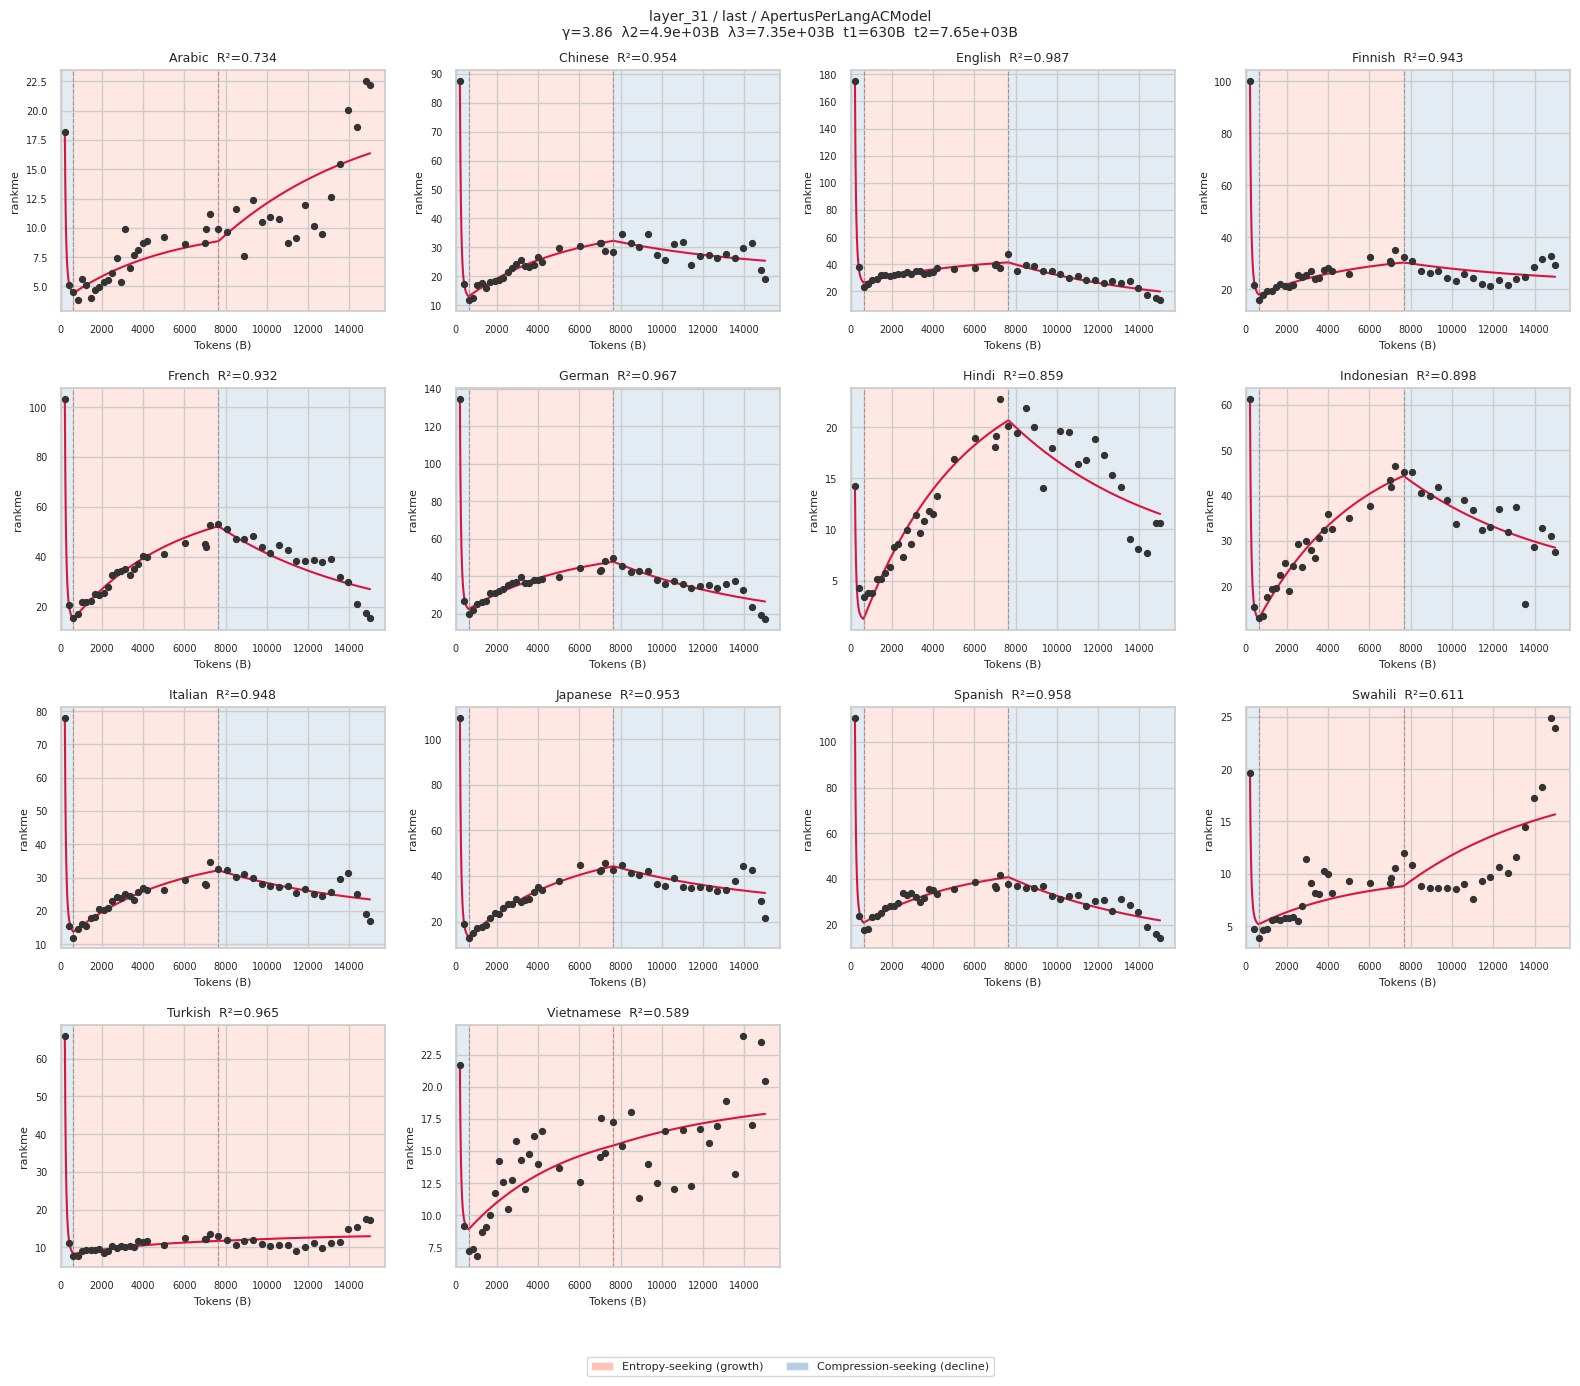

In [19]:
plot_fitted_laws(apertus_params_per_language_df, apertus_df, model=apertus_model_per_lang)

### Dual-tail model (separate growth and decay)

The per-language model achieves R² above 0.90 for most languages, but still does not fit well the expanding languages. We replace the single phase-3 term with two mutually exclusive basis functions ($C_{3,d}, C_{3,g} \ge 0$, exactly one active per language) to model the expanding and compressing regimes separately. Both are instances of the unified basis

$$b(t, \lambda) = \left(e^{(t-t_2)/\lambda} - 1\right)\mathbf{1}[t > t_2]$$

which saturates in $(-1, 0]$ when $\lambda < 0$ and grows exponentially in $[0, +\infty)$ when $\lambda > 0$. Our model becomes:

$$\hat{R}(t) = \begin{cases} \alpha + A\,t^{-\gamma} & t \le t_1 \\ \alpha + A\,P_1 + C_2\!\left(1 - e^{-(t-t_1)/\lambda_2}\right) & t_1 < t \le t_2 \\ \alpha + A\,P_1 + C_2\,Q_2 + C_{3,d}\,b(t,-\lambda_3) & t > t_2 \;\text{(decay)} \\ \alpha + A\,P_1 + C_2\,Q_2 + C_{3,g}\,b(t,+\lambda_3) & t > t_2 \;\text{(growth)} \end{cases}$$

where $P_1 = t_1^{-\gamma}$ and $Q_2 = 1 - e^{-(t_2-t_1)/\lambda_2}$.

In [20]:
apertus_model_per_lang_dual = ApertusDualTailACModel()
apertus_params_per_language_dual_df = fit_rankme_from_df(apertus_df, "layer_31", "last", model=apertus_model_per_lang_dual, changepoints=[630, 7652], t_scale=1000)
display_parameter_tables(apertus_params_per_language_dual_df)

Shared parameters:


,gamma,lam2,lam3,t_change,t_change2
0,3.8647,4893.3076,7348.0,630.0,7652.0


Per-language parameters:


,language,alpha,A,C2,C3_decay,C3_growth,r2
0,Arabic,4.2313,1.314669e+10,5.8085,0.0000,5.8644,0.8260
1,Chinese,11.9585,7.137192e+10,25.2331,-10.9224,0.0000,0.9540
2,English,24.3627,1.423456e+11,19.5925,-33.9532,0.0000,0.9871
3,Finnish,16.7289,7.868439e+10,16.1765,-8.6619,0.0000,0.9432
4,French,13.8029,8.427815e+10,48.8278,-39.9505,0.0000,0.9315
5,German,20.8562,1.071202e+11,33.2150,-33.5985,0.0000,0.9669
6,Hindi,1.0436,1.255674e+10,25.5115,-14.4949,0.0000,0.8595
7,Indonesian,12.1398,4.625773e+10,41.3152,-24.9659,0.0000,0.8984
8,Italian,12.8067,6.138309e+10,24.2430,-13.7906,0.0000,0.9481
9,Japanese,12.0235,9.180147e+10,40.5623,-18.5969,0.0000,0.9528


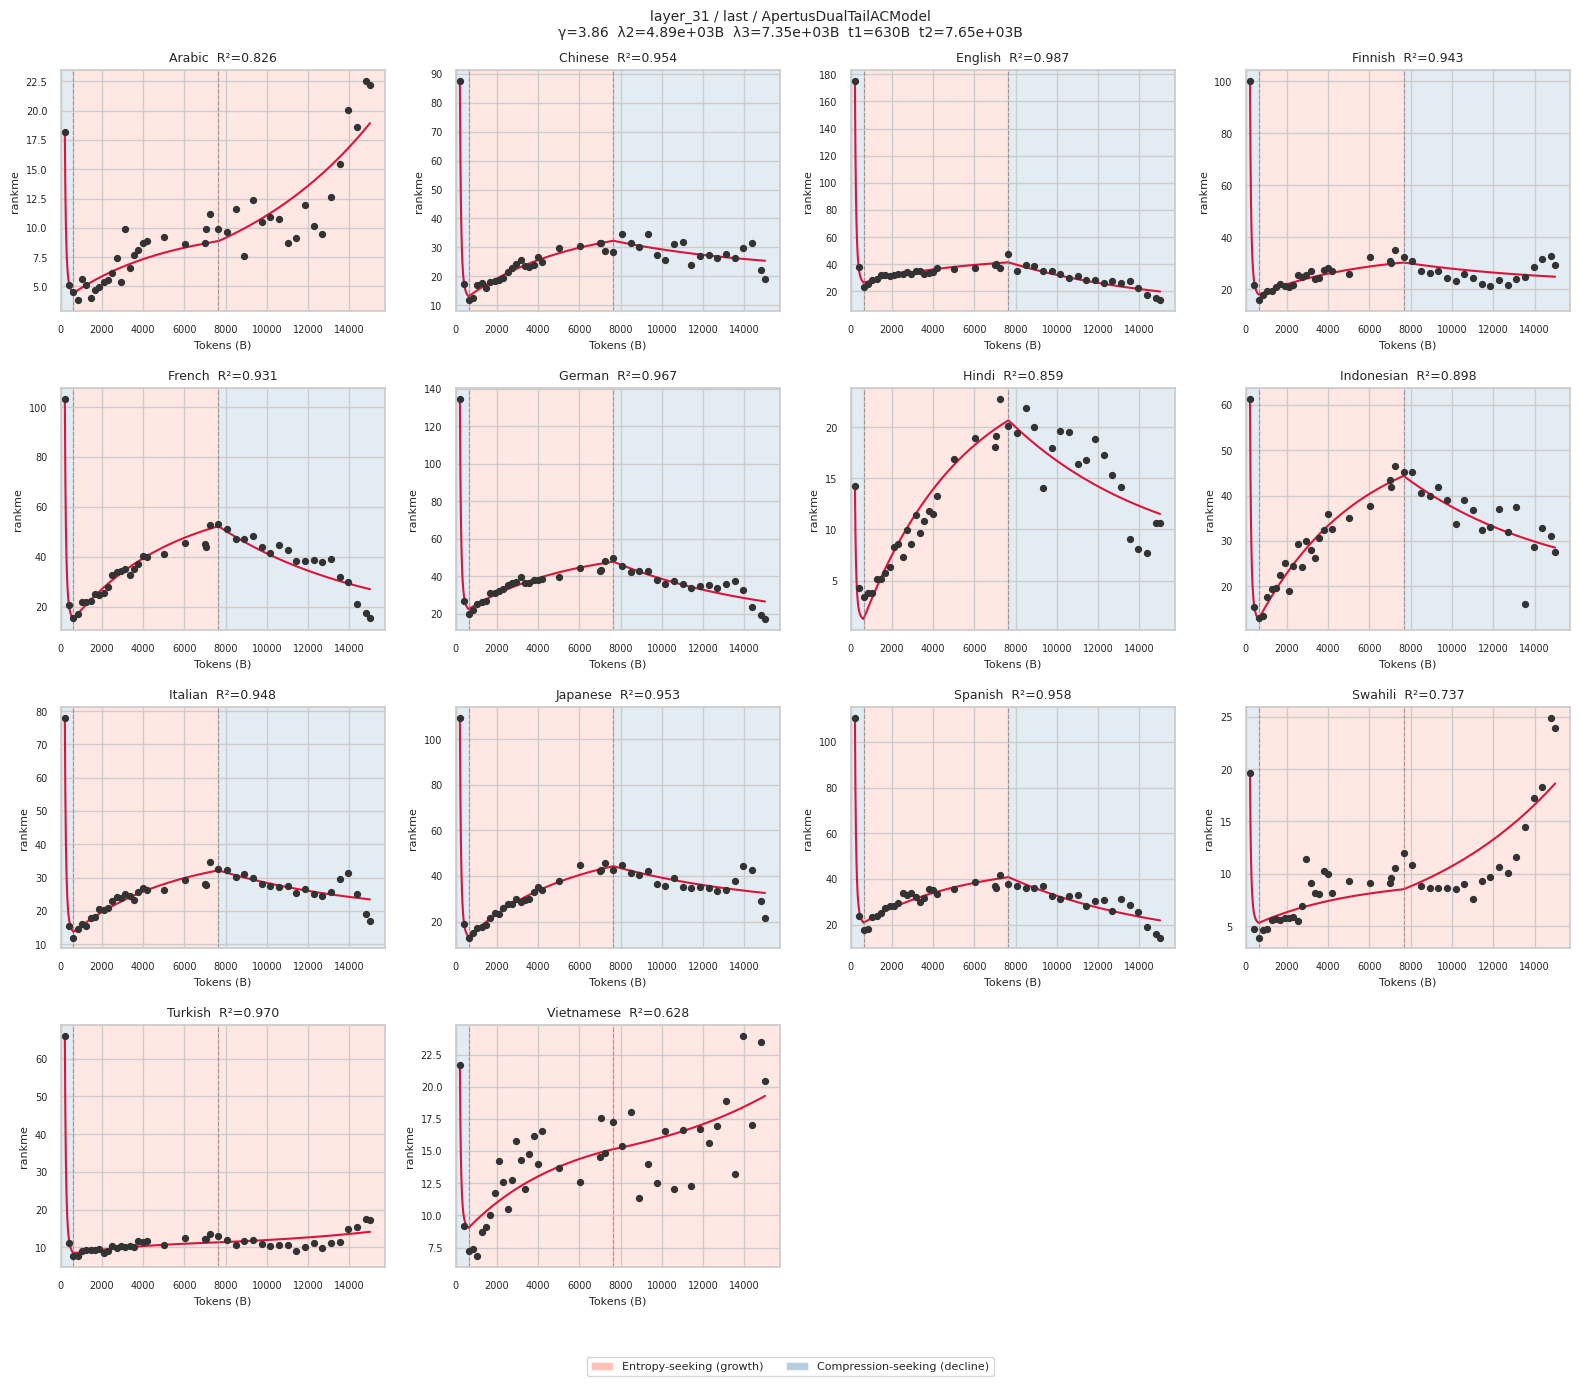

In [21]:
plot_fitted_laws(apertus_params_per_language_dual_df, apertus_df, model=apertus_model_per_lang_dual)

### Dual-$\lambda$ model (separate timescales per phase-3 branch)

The dual-tail model forces a single $\lambda_3$ for both decay and growth, but these dynamics have different timescales. We therefore fit separate $\lambda_{3,d}$ and $\lambda_{3,g}$, keeping $C_{3,d}, C_{3,g} \ge 0$ mutually exclusive per language:

$$\hat{R}(t) = \begin{cases} \alpha + A\,t^{-\gamma} & t \le t_1 \\ \alpha + A\,P_1 + C_2\!\left(1 - e^{-(t-t_1)/\lambda_2}\right) & t_1 < t \le t_2 \\ \alpha + A\,P_1 + C_2\,Q_2 + C_{3,d}\,b(t,-\lambda_{3,d}) & t > t_2 \;\text{(decay)} \\ \alpha + A\,P_1 + C_2\,Q_2 + C_{3,g}\,b(t,+\lambda_{3,g}) & t > t_2 \;\text{(growth)} \end{cases}$$

where $b(t,\lambda)$ is as defined above, $P_1 = t_1^{-\gamma}$, and $Q_2 = 1 - e^{-(t_2-t_1)/\lambda_2}$.

In [22]:
apertus_model_dual_lam = ApertusDualLamACModel()
apertus_params_dual_lam_df = fit_rankme_from_df(apertus_df, "layer_31", "last", model=apertus_model_dual_lam, changepoints=[630, 7652], t_scale=1000)
display_parameter_tables(apertus_params_dual_lam_df)

Shared parameters:


,gamma,lam2,lam3_decay,lam3_growth,t_change,t_change2
0,3.8646,4930.4459,7348.0,1126.7679,630.0,7652.0


Per-language parameters:


,language,alpha,A,C2,C3_decay,C3_growth,r2
0,Arabic,3.6610,1.370111e+10,8.2556,0.0000,0.0210,0.9186
1,Chinese,11.9755,7.129704e+10,25.3104,-10.9442,0.0000,0.9540
2,English,24.3740,1.422186e+11,19.6564,-33.9729,0.0000,0.9871
3,Finnish,16.7415,7.860791e+10,16.2219,-8.6728,0.0000,0.9432
4,French,13.8328,8.418006e+10,48.9849,-39.9982,0.0000,0.9316
5,German,20.8793,1.070102e+11,33.3149,-33.6259,0.0000,0.9669
6,Hindi,1.0574,1.253288e+10,25.5980,-14.5230,0.0000,0.8599
7,Indonesian,12.1655,4.619464e+10,41.4472,-25.0056,0.0000,0.8985
8,Italian,12.8237,6.131634e+10,24.3159,-13.8105,0.0000,0.9480
9,Japanese,12.0504,9.170011e+10,40.6876,-18.6327,0.0000,0.9528


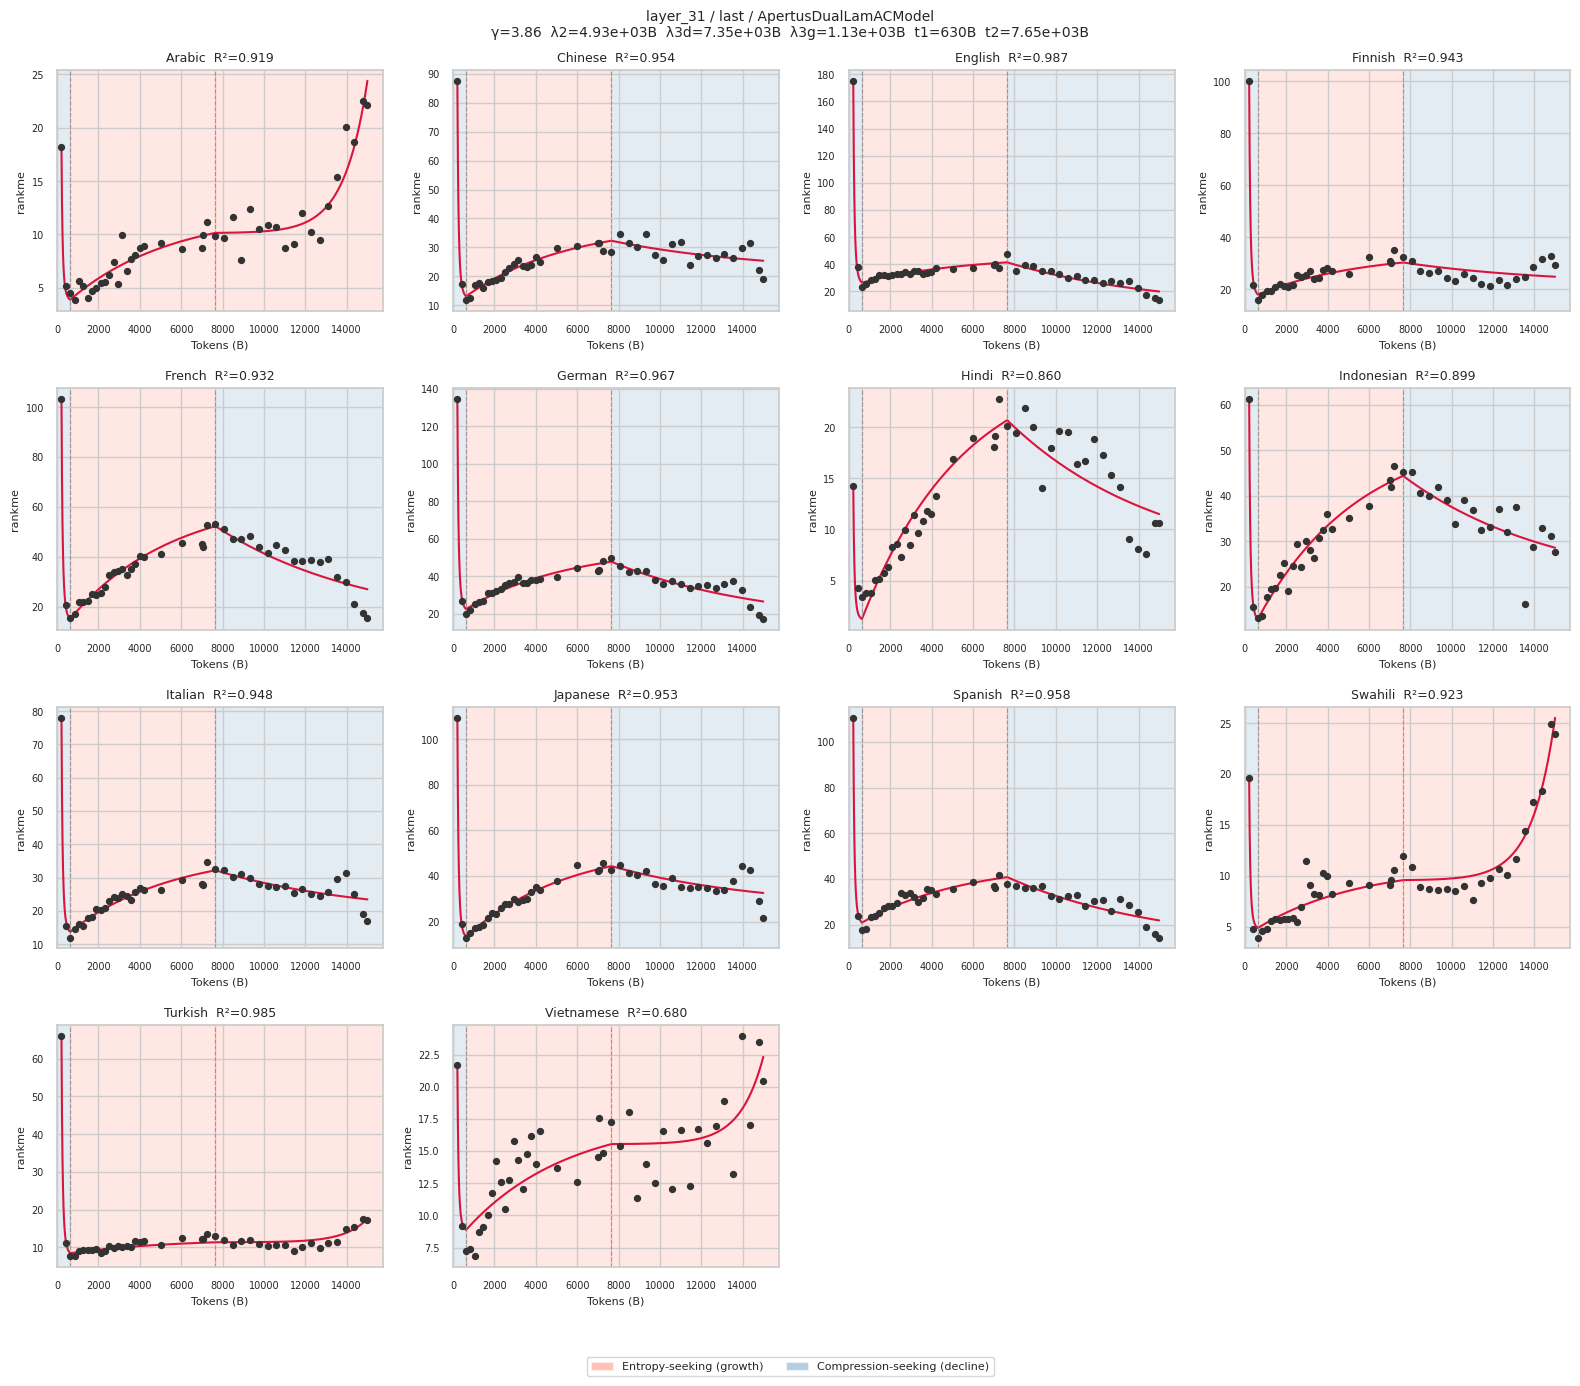

In [23]:
plot_fitted_laws(apertus_params_dual_lam_df, apertus_df, model=apertus_model_dual_lam)

Allowing separate timescales for the two branches brings all languages except Vietnamese (R² = 0.68) above R² = 0.86, with most above 0.90.

## Concluding observations

**FuxiTranyu.** All 14 languages follow nearly identical shapes, differing only in offset and magnitude. A fully shared model therefore achieves R² above 0.88 for 13 languages, with Chinese (R² = 0.69) as the main exception. Making $A$ and $C$ per-language while keeping $\gamma$ and $\lambda$ shared brings all languages above R² = 0.90.

**Apertus.** The third phase breaks cross-lingual shape agreement: Arabic, Hindi, Swahili and Vietnamese show a final RankMe expansion while the remaining languages compress. This causes shared models to fail on the expanding group (R² < 0.20 in the three-phase shared model). Progressively decoupling parameters (per-language $A$, $C_2$, $C_3$, then separate decay and growth branches with independent timescales) recovers a good fit for most languages, but Vietnamese remains problematic (R² ≈ 0.68).